# Project Description
The purupose of this project is to compare the amount of precipitation between Seattle, Washington and Grand Rapids, Michigan. Precipitation data has been pulled from publicly available web sources and identical date ranges are compared. Links to the data are contained in the code that loads the data into the notebook.

This first section of code loads necessary packages and sets the default plotting style

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

This next section of code loads the data in. Links are contained in the code

In [4]:
# Load data
df_seattle = pd.read_csv('https://raw.githubusercontent.com/kderosia31/weather/refs/heads/main/data/seattle_rain.csv')
df_grandrapid = pd.read_csv('https://raw.githubusercontent.com/kderosia31/weather/refs/heads/main/data/grandrapids_rain.csv')

This portion of code checks the data frames from the seattle and grand rapids data sets. It then converts the date column from string type to datetime type and checks to makes sure the code worked.

In [6]:
## Exploratory analysis
df_seattle.info()
df_grandrapid.info()
## Date column is string, needs to be date
df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])
df_grandrapid['DATE'] = pd.to_datetime(df_grandrapid['DATE'])
## Check if it worked
df_seattle['DATE']
df_grandrapid['DATE']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  1658 non-null   object        
 1   NAME     1658 non-null   object        
 2   DATE     1658 non-null   datetime64[ns]
 3   DAPR     23 non-null     float64       
 4   MDPR     23 non-null     float64       
 5   PRCP     1636 non-null   float64       
 6   SNOW     353 non-null    float64       
 7   SNWD     66 non-null     float64       
 8   WESD     15 non-null     float64       
 9   WESF     28 non-null     float64       
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 129.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1759 entries, 0 to 1758
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  1759 non-null   object        
 1   NAME     1759 non-null   object   

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1754   2022-12-27
1755   2022-12-28
1756   2022-12-29
1757   2022-12-30
1758   2022-12-31
Name: DATE, Length: 1759, dtype: datetime64[ns]

This code section checks the date range for seattle

In [7]:
## Check that date range is correct
df_seattle['DATE'].agg(['min', 'max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

This section checks the date range for grand rapids

In [8]:
df_grandrapid['DATE'].agg(['min', 'max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

The next code section joins the grand rapids and seattle data frames into one, new data frame containing the dates and precipitation from each city

In [9]:
# Join data
df_joined = df_grandrapid[['DATE', 'PRCP']].merge(df_seattle[['DATE', 'PRCP']], on='DATE', how='outer')

The next code section checks the new joined data frame

In [10]:
#check joining
df_joined.head()

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.02,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.04,0.00
3,2018-01-04,0.06,0.00
4,2018-01-05,0.00,0.25


The next section creates a tidy data frame in long format and checks it

In [11]:
#create tidy data frame
df_joined = pd.melt(df_joined, id_vars='DATE', var_name='city', value_name='precipitation')
#check data frame
df_joined.head()

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.02
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.04
3,2018-01-04,PRCP_x,0.06
4,2018-01-05,PRCP_x,0.00


This section changes the city name values to either GR or SEA depending on if the value is from grand rapids or seattle

In [12]:
#Change city names
df_joined.loc[df_joined['city'] == 'PRCP_x', 'city'] = 'GR'
df_joined.loc[df_joined['city'] == 'PRCP_y', 'city'] = 'SEA'
#Check
df_joined.head

<bound method NDFrame.head of            DATE city  precipitation
0    2018-01-01   GR           0.02
1    2018-01-02   GR           0.00
2    2018-01-03   GR           0.04
3    2018-01-04   GR           0.06
4    2018-01-05   GR           0.00
...         ...  ...            ...
3639 2022-06-28  SEA           0.00
3640 2022-07-31  SEA           0.00
3641 2022-09-08  SEA           0.00
3642 2022-09-15  SEA           0.00
3643 2022-11-04  SEA           0.37

[3644 rows x 3 columns]>

The next code section searches for the total number of missing values in the joined data frame

In [13]:
#Check for missing data
df_joined.isna().sum()

DATE               0
city               0
precipitation    262
dtype: int64

This checks for how many missing values are from seattle

In [14]:
#Missing some precipitation data
# how much from each city
df_joined.loc[df_joined['city'] == 'SEA', 'precipitation'].isna().sum()

186

This checks for how many missing values are from grand rapids

In [15]:
df_joined.loc[df_joined['city'] == 'GR', 'precipitation'].isna().sum()

76

The next code section creates a new column called "day_of_year" that lists which day of the week the corresponding date was

In [16]:
## replace missing values with average
df_joined['day_of_year'] = pd.DatetimeIndex(df_joined['DATE']).day_of_year

Checks new column

In [17]:
df_joined.head()

,DATE,city,precipitation,day_of_year
0,2018-01-01,GR,0.02,1
1,2018-01-02,GR,0.00,2
2,2018-01-03,GR,0.04,3
3,2018-01-04,GR,0.06,4
4,2018-01-05,GR,0.00,5


This calculates the mean precipitation grouped by the day of the year for seattle

In [18]:
## mean precipitation for each day in Seattle
mean_day_precipitation_sea = df_joined.loc[
    df_joined['city'] == 'SEA',
    ['precipitation', 'day_of_year']
    ].groupby(
        'day_of_year'
    ).mean()

This calculates the mean precipitation grouped by the day of the year for grand rapids

In [19]:
# mean by day in GR
mean_day_precipitation_gr = df_joined.loc[
    df_joined['city'] == 'GR',
    ['precipitation', 'day_of_year']
    ].groupby(
        'day_of_year'
    ).mean()

The next code chunk identifies the indicies of missing values from both seattle and grand rapids

In [20]:
#indicies of missing data in seattle
indicies_sea = np.where(df_joined['precipitation'].isna() == True)[0]
#same for gr
indicies_gr = np.where(df_joined['precipitation'].isna() == True)[0]

Next, the missing data is replaced by the average precipitation value on those days

In [21]:
#replace missing seattle
for index in indicies_sea:
    df_joined.loc[index, 'precipitation'] = mean_day_precipitation_sea.loc[df_joined.loc[index, 'day_of_year']].values[0]

In [22]:
#replace missing gr
for index in indicies_gr:
    df_joined.loc[index, 'precipitation'] = mean_day_precipitation_gr.loc[df_joined.loc[index, 'day_of_year']].values[0]

Check that the replacement worked

In [23]:
df_joined.isna().sum()

DATE             0
city             0
precipitation    1
day_of_year      0
dtype: int64

The next section creates a boxplot to show rainfall between the cities

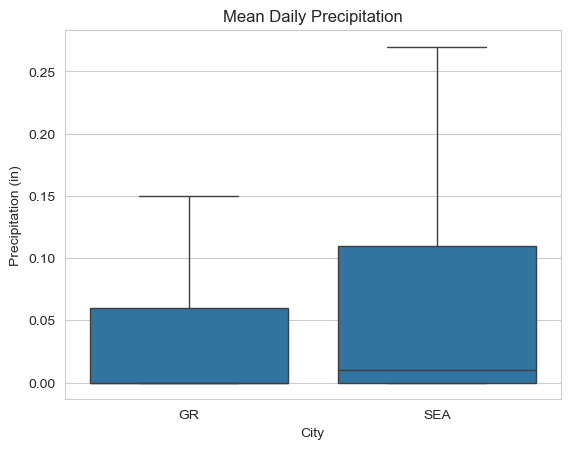

In [24]:
## Exploratory graphs
# mean in each city
# df_joined[['city', 'precipitation']].groupby('city').mean()
sns.boxplot(data = df_joined, x = 'city', y = 'precipitation', showfliers = False)

plt.ylabel('Precipitation (in)')
plt.xlabel('City')
plt.title('Mean Daily Precipitation')
plt.show()

The boxplots show that seattle has a higher median rainfall, as evidenced by the horizontal bar in the boxplot being higher. Additionally, the larger whisker on seattles boxplot indicates more precipitation.

This code computes summary stats

Code below exports clean data frame

In [26]:
df_joined.to_csv('clean_seattle_grandrapids_weather.csv', encoding = 'utf-8-sig', index=False)

<function matplotlib.pyplot.show(close=None, block=None)>

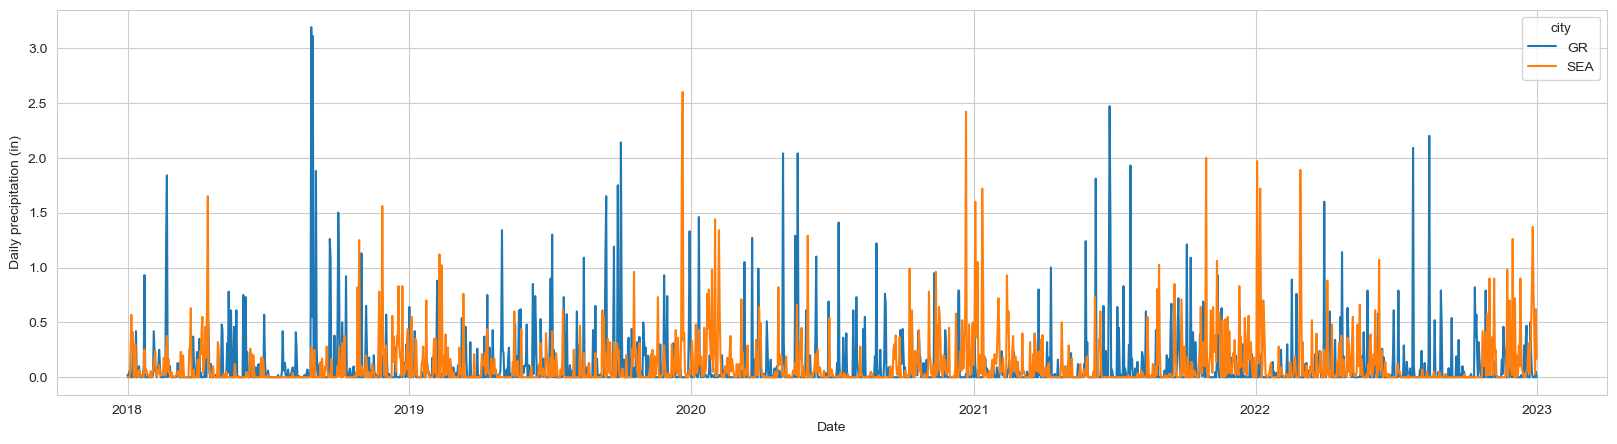

In [28]:
plt.figure(figsize=(20,5))

sns.lineplot(data = df_joined, x = "DATE", y = "precipitation", hue= "city")

plt.xlabel('Date')
plt.ylabel('Daily precipitation (in)')

plt.show

rainfall over time

In [31]:
df_joined[['city', 'precipitation']].groupby('city').describe()

precipitation                                                
             count      mean       std  min  25%   50%   75%   max
city                                                              
GR          1821.0  0.105215  0.281108  0.0  0.0  0.00  0.06  3.19
SEA         1822.0  0.110104  0.239784  0.0  0.0  0.01  0.11  2.60

Text(0.5, 1.0, 'mean daily precipitation')

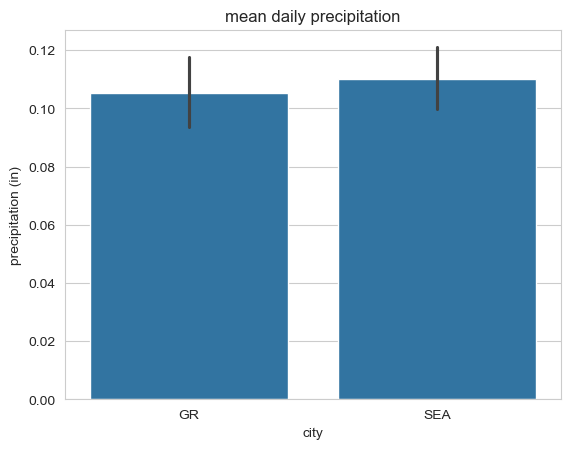

In [35]:
sns.barplot(data=df_joined, x = 'city', y = 'precipitation')

plt.ylabel('precipitation (in)')
plt.xlabel('city')
plt.title('mean daily precipitation')